In [1]:
import os
import re
import json
import csv
import random
import pandas as pd
from pyfaidx import Fasta
from tqdm import tqdm

# ================= 1) CONFIG =================
GTF_FILE = r"C:\Users\dotru\STUDIE\FPTU\AiTA_Lab\gencode.v49.basic.annotation.gtf"
FASTA_FILE = r"C:\Users\dotru\STUDIE\FPTU\AiTA_Lab\Homo_sapiens.GRCh38.dna.primary_assembly.fa"
OUT_DIR = r"C:\Users\dotru\STUDIE\FPTU\AiTA_Lab\data\ver2\dataset3"

TARGET_GENE = "CFTR"
TARGET_TRANSCRIPT = "ENST00000003084"   # no version
WINDOW = 300
SEQ_LEN = 2 * WINDOW + 1
SEED = 42

FULL_CSV = os.path.join(OUT_DIR, "cftr_interpretability_full.csv")
BALANCED_CSV = os.path.join(OUT_DIR, "cftr_interpretability_balanced.csv")
MOTIF_JSON = os.path.join(OUT_DIR, "cftr_motif_config.json")

random.seed(SEED)

# ================= 2) UTILS =================
def get_detailed_region(pos, cftr_df):
    """
    Xác định vị trí pos thuộc Exon/Intron nào và phân nhóm first/middle/last.
    """
    max_ex = int(cftr_df["exon_number"].max())
    
    # 1. Kiểm tra xem có nằm trong Exon nào không
    for _, row in cftr_df.iterrows():
        if row['start'] <= pos <= row['end']:
            ex_num = int(row['exon_number'])
            # Phân loại group: Exon 1 là first, Exon cuối là last, còn lại middle
            group = "first" if ex_num == 1 else ("last" if ex_num == max_ex else "middle")
            return f"exon_{ex_num}", group
            
    # 2. Nếu không nằm trong Exon, tìm xem thuộc Intron nào
    # Sắp xếp cftr_df theo tọa độ tăng dần để tìm khoảng giữa các exon
    cftr_sorted = cftr_df.sort_values("start")
    for i in range(len(cftr_sorted) - 1):
        prev_ex = cftr_sorted.iloc[i]
        next_ex = cftr_sorted.iloc[i+1]
        
        if prev_ex['end'] < pos < next_ex['start']:
            intron_num = int(prev_ex['exon_number'])
            # Intron 1 (nối exon 1-2) là first
            # Intron cuối (nối exon 26-27) là last
            group = "first" if intron_num == 1 else ("last" if intron_num == (max_ex - 1) else "middle")
            return f"intron_{intron_num}", group

    return "outside_transcript", "all"

def parse_attributes(attr):
    fields = {}
    for part in attr.strip().split(";"):
        part = part.strip()
        if not part:
            continue
        if " " not in part:
            continue
        k, v = part.split(" ", 1)
        fields[k] = v.strip().strip('"')
    return fields

def strip_version(x):
    return str(x).split(".")[0]

def normalize_chrom(chrom_name):
    s = str(chrom_name).strip()
    if s.lower().startswith("chr"):
        return s[3:]
    return s

def fasta_key_from_chrom(genome, chrom):
    c = normalize_chrom(chrom)
    if c in genome:
        return c
    if ("chr" + c) in genome:
        return "chr" + c
    return None

def revcomp(seq):
    tbl = str.maketrans("ATCGN", "TAGCN")
    return seq.translate(tbl)[::-1]

def get_sequence_strict(genome, raw_chrom, center_pos_1based, strand, window):
    key = fasta_key_from_chrom(genome, raw_chrom)
    if key is None:
        return None

    # pyfaidx slicing: 0-based, end exclusive
    start0 = center_pos_1based - 1 - window
    end0_excl = center_pos_1based + window

    if start0 < 0 or end0_excl > len(genome[key]):
        return None

    seq = genome[key][start0:end0_excl].seq.upper()
    if len(seq) != (2 * window + 1):
        return None
    if "N" in seq:
        return None

    if strand == "-":
        seq = revcomp(seq)

    return seq

def classify_group(exon_number, max_exon_number):
    if exon_number == 1:
        return "first"
    if exon_number == max_exon_number:
        return "last"
    return "middle"

# ================= 3) PARSE GTF =================
print("Loading GTF...")
gtf = pd.read_csv(
    GTF_FILE,
    sep="\t",
    comment="#",
    header=None,
    names=["chrom", "source", "feature", "start", "end", "score", "strand", "frame", "attribute"],
    usecols=[0, 2, 3, 4, 6, 8]
)

exon_rows = gtf[gtf["feature"] == "exon"].copy()

parsed = exon_rows["attribute"].map(parse_attributes)
exon_rows["gene_name"] = parsed.map(lambda d: d.get("gene_name", ""))
exon_rows["transcript_id_raw"] = parsed.map(lambda d: d.get("transcript_id", ""))
exon_rows["transcript_id"] = exon_rows["transcript_id_raw"].map(strip_version)
exon_rows["exon_number"] = parsed.map(lambda d: int(d.get("exon_number", "0")) if d.get("exon_number", "").isdigit() else 0)

cftr = exon_rows[
    (exon_rows["gene_name"] == TARGET_GENE) &
    (exon_rows["transcript_id"] == TARGET_TRANSCRIPT)
].copy()

if cftr.empty:
    raise RuntimeError("No exon rows found for target transcript. Check TARGET_TRANSCRIPT and GTF version.")

cftr = cftr.sort_values("exon_number").reset_index(drop=True)
chrom = cftr["chrom"].iloc[0]
strand = cftr["strand"].iloc[0]
max_exon_number = int(cftr["exon_number"].max())

print(f"Found {len(cftr)} exons for {TARGET_GENE} {TARGET_TRANSCRIPT}, strand={strand}, chrom={chrom}")

# ================= 4) BUILD TRUE SITES =================
true_sites = []
num_junctions = len(cftr) - 1 # Có 26 điểm nối cho 27 exons

for i in range(num_junctions):
    ex = cftr.iloc[i]
    next_ex = cftr.iloc[i + 1]
    
    # Xác định junction này là thứ mấy
    junction_idx = i + 1 # Junction 1, 2, ..., 26
    
    # Gán group dựa trên thứ tự junction
    if junction_idx == 1:
        group = "first"
    elif junction_idx == num_junctions:
        group = "last"
    else:
        group = "middle"

    if strand == "+":
        donor_pos = int(ex["end"]) + 1
        acceptor_pos = int(next_ex["start"]) - 1
    else:
        donor_pos = int(ex["start"]) - 1
        acceptor_pos = int(next_ex["end"]) + 1

    true_sites.append({
        "chrom": chrom, "pos": donor_pos, "strand": strand,
        "site_type": "donor", "label": 1, "group_position": group,
        "exon_number": int(ex["exon_number"]),
        "region_name": f"intron_{int(ex['exon_number'])}_true_donor",
        "is_true_site": 1
    })
    true_sites.append({
        "chrom": chrom, "pos": acceptor_pos, "strand": strand,
        "site_type": "acceptor", "label": 2, "group_position": group,
        "exon_number": int(next_ex["exon_number"]),
        "region_name": f"intron_{int(ex['exon_number'])}_true_acceptor",
        "is_true_site": 1
    })

true_df = pd.DataFrame(true_sites)

# ================= 5) LOAD GENOME + EXTRACT TRUE SEQS =================
print("Loading FASTA...")
genome = Fasta(FASTA_FILE, sequence_always_upper=True)

seqs = []
for _, r in tqdm(true_df.iterrows(), total=len(true_df), desc="Extract true-site seq"):
    s = get_sequence_strict(genome, r["chrom"], int(r["pos"]), r["strand"], WINDOW)
    seqs.append(s)

true_df["sequence"] = seqs
true_df = true_df[true_df["sequence"].notna()].copy()
true_df = true_df[true_df["sequence"].str.len() == SEQ_LEN].copy()

if true_df.empty:
    raise RuntimeError("No valid true-site sequence extracted.")

# ================= 6) DISCOVER TRUE MOTIFS =================
def center_motif(seq, site_type):
    c = WINDOW
    if site_type == "donor":
        return seq[c:c+2]      # center G + next
    else:
        return seq[c-1:c+1]    # prev + center G

true_df["motif"] = true_df.apply(lambda x: center_motif(x["sequence"], x["site_type"]), axis=1)

donor_motifs = sorted(true_df[true_df["site_type"] == "donor"]["motif"].value_counts().index.tolist())
acceptor_motifs = sorted(true_df[true_df["site_type"] == "acceptor"]["motif"].value_counts().index.tolist())

print("Discovered donor motifs:", donor_motifs)
print("Discovered acceptor motifs:", acceptor_motifs)

# ================= 7) SCAN TRANSCRIPT RANGE FOR PSEUDO SITES =================
tx_min = int(cftr["start"].min())
tx_max = int(cftr["end"].max())

true_key = set((r["site_type"], int(r["pos"])) for _, r in true_df.iterrows())

pseudo_rows = []
for pos in tqdm(range(tx_min, tx_max + 1), desc="Scan pseudo-sites"):
    seq = get_sequence_strict(genome, chrom, pos, strand, WINDOW)
    if seq is None:
        continue

    donor_m = seq[WINDOW:WINDOW+2]
    acceptor_m = seq[WINDOW-1:WINDOW+1]

    # Lấy thông tin vùng chi tiết cho tọa độ hiện tại
    region_name, group_pos = get_detailed_region(pos, cftr)

    # Donor candidates
    if donor_m in donor_motifs and ("donor", pos) not in true_key:
        pseudo_rows.append({
            "chrom": chrom, "pos": pos, "strand": strand,
            "site_type": "donor", "label": 0, "group_position": group_pos,
            "exon_number": 0, "region_name": f"{region_name}_pseudo", 
            "is_true_site": 0, "sequence": seq, "motif": donor_m
        })

    # Acceptor candidates
    if acceptor_m in acceptor_motifs and ("acceptor", pos) not in true_key:
        pseudo_rows.append({
            "chrom": chrom, "pos": pos, "strand": strand,
            "site_type": "acceptor", "label": 0, "group_position": group_pos,
            "exon_number": 0, "region_name": f"{region_name}_pseudo", 
            "is_true_site": 0, "sequence": seq, "motif": acceptor_m
        })

pseudo_df = pd.DataFrame(pseudo_rows)

# ================= 8) MERGE FULL DATA =================
full_df = pd.concat([true_df, pseudo_df], ignore_index=True)
full_df["gene_name"] = TARGET_GENE
full_df["gene_id"] = "ENSG00000001626"
full_df["transcript_id"] = TARGET_TRANSCRIPT
full_df["site_id"] = full_df.apply(
    lambda x: f"{x['gene_name']}_{x['chrom']}_{int(x['pos'])}_{x['strand']}_{x['site_type']}",
    axis=1
)

# Reorder columns for notebook compatibility
cols = [
    "site_id", "sequence", "label", "site_type", "group_position",
    "chrom", "pos", "strand", "motif", "is_true_site",
    "gene_name", "gene_id", "transcript_id", "exon_number", "region_name"
]
full_df = full_df[cols]

# ================= 9) BUILD BALANCED DATA =================
# Balance by site_type and label
balanced_parts = []
for st in ["donor", "acceptor"]:
    pos_st = full_df[(full_df["site_type"] == st) & (full_df["label"] > 0)]
    neg_st = full_df[(full_df["site_type"] == st) & (full_df["label"] == 0)]

    n = min(len(pos_st), len(neg_st))
    if n == 0:
        continue

    pos_sample = pos_st.sample(n=n, random_state=SEED)
    neg_sample = neg_st.sample(n=n, random_state=SEED)
    balanced_parts.extend([pos_sample, neg_sample])

balanced_df = pd.concat(balanced_parts, ignore_index=True).sample(frac=1.0, random_state=SEED)

# ================= 10) SAVE =================
os.makedirs(OUT_DIR, exist_ok=True)
full_df.to_csv(FULL_CSV, index=False)
balanced_df.to_csv(BALANCED_CSV, index=False)

motif_cfg = {
    "gene_name": TARGET_GENE,
    "gene_id": "ENSG00000001626",
    "transcript_id": TARGET_TRANSCRIPT,
    "chrom": chrom,
    "strand": strand,
    "window": WINDOW,
    "seq_len": SEQ_LEN,
    "motif_rules": {
        "donor": donor_motifs,
        "acceptor": acceptor_motifs
    }
}
with open(MOTIF_JSON, "w", encoding="utf-8") as f:
    json.dump(motif_cfg, f, indent=2)

print("Saved full:", FULL_CSV, "rows=", len(full_df))
print("Saved balanced:", BALANCED_CSV, "rows=", len(balanced_df))
print("Saved motif config:", MOTIF_JSON)

Loading GTF...
Found 27 exons for CFTR ENST00000003084, strand=+, chrom=chr7
Loading FASTA...


Extract true-site seq: 100%|██████████| 52/52 [00:00<00:00, 5056.31it/s]


Discovered donor motifs: ['GT']
Discovered acceptor motifs: ['AG']


Scan pseudo-sites: 100%|██████████| 188641/188641 [10:08<00:00, 310.26it/s] 


Saved full: C:\Users\dotru\STUDIE\FPTU\AiTA_Lab\data\ver2\dataset3\cftr_interpretability_full.csv rows= 22306
Saved balanced: C:\Users\dotru\STUDIE\FPTU\AiTA_Lab\data\ver2\dataset3\cftr_interpretability_balanced.csv rows= 104
Saved motif config: C:\Users\dotru\STUDIE\FPTU\AiTA_Lab\data\ver2\dataset3\cftr_motif_config.json


🚀 Đã load 22306 dòng dữ liệu.

--- [1] THỐNG KÊ CƠ BẢN ---
Số lượng Label:
label
0    22254
1       26
2       26
Name: count, dtype: int64
Số lượng Site Type:
site_type
acceptor    12178
donor       10128
Name: count, dtype: int64
Phân bố Group Position:
group_position
middle    18981
first      2935
last        390
Name: count, dtype: int64

--- [2] VALIDATION LOGIC SINH HỌC ---
Số dòng sai độ dài (601bp): 0
Motifs tìm thấy ở Donor: <ArrowStringArray>
['GT']
Length: 1, dtype: str
Motifs tìm thấy ở Acceptor: <ArrowStringArray>
['AG']
Length: 1, dtype: str

--- [3] PHÂN TÍCH TRUE VS PSEUDO ---
           Pseudo (Label 0)  True Site (Label 1/2)
site_type                                         
acceptor              12152                     26
donor                 10102                     26


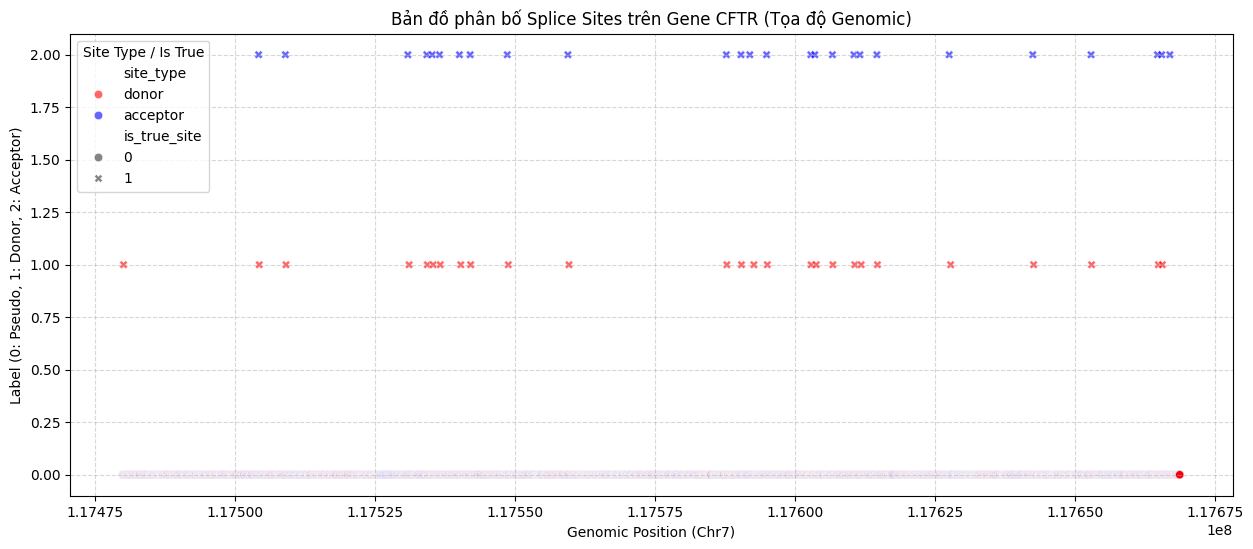


--- [4] VỊ TRÍ CÁC PSEUDO-SITES ---
Top 10 vùng chứa nhiều Pseudo-sites nhất:
region_name
intron_11_pseudo    3390
intron_1_pseudo     2910
intron_3_pseudo     2454
intron_22_pseudo    1724
intron_21_pseudo    1486
intron_24_pseudo    1351
intron_23_pseudo    1278
intron_10_pseudo    1276
intron_15_pseudo     899
intron_9_pseudo      754
Name: count, dtype: int64


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đường dẫn file của bạn
FILE_PATH = r"C:\Users\dotru\STUDIE\FPTU\AiTA_Lab\data\ver2\dataset3\cftr_interpretability_full.csv"

def analyze_cftr_data(path):
    df = pd.read_csv(path)
    print(f"🚀 Đã load {len(df)} dòng dữ liệu.")
    
    # 1. Kiểm tra cấu trúc cơ bản
    print("\n--- [1] THỐNG KÊ CƠ BẢN ---")
    print(f"Số lượng Label:\n{df['label'].value_counts()}")
    print(f"Số lượng Site Type:\n{df['site_type'].value_counts()}")
    print(f"Phân bố Group Position:\n{df['group_position'].value_counts()}")

    # 2. Kiểm tra Logic Sinh Học
    print("\n--- [2] VALIDATION LOGIC SINH HỌC ---")
    
    # Check độ dài sequence
    df['seq_len'] = df['sequence'].str.len()
    invalid_len = df[df['seq_len'] != 601]
    print(f"Số dòng sai độ dài (601bp): {len(invalid_len)}")
    
    # Check Motif Consistency
    # Donor label 1/0 phải là GT/GC; Acceptor label 2/0 phải là AG
    donor_check = df[df['site_type'] == 'donor']['motif'].unique()
    acc_check = df[df['site_type'] == 'acceptor']['motif'].unique()
    print(f"Motifs tìm thấy ở Donor: {donor_check}")
    print(f"Motifs tìm thấy ở Acceptor: {acc_check}")

    # 3. Thống kê True Site vs Pseudo Site
    print("\n--- [3] PHÂN TÍCH TRUE VS PSEUDO ---")
    summary = df.groupby(['site_type', 'is_true_site']).size().unstack(fill_value=0)
    summary.columns = ['Pseudo (Label 0)', 'True Site (Label 1/2)']
    print(summary)

    # 4. TRỰC QUAN HÓA (VISUALIZATION)
    plt.figure(figsize=(15, 6))
    
    # Vẽ phân bố các site dọc theo chiều dài Gen (Tọa độ Genomic)
    sns.scatterplot(
        data=df, 
        x='pos', 
        y='label', 
        hue='site_type', 
        style='is_true_site',
        alpha=0.6,
        palette={'donor': 'red', 'acceptor': 'blue'}
    )
    
    plt.title('Bản đồ phân bố Splice Sites trên Gene CFTR (Tọa độ Genomic)')
    plt.xlabel('Genomic Position (Chr7)')
    plt.ylabel('Label (0: Pseudo, 1: Donor, 2: Acceptor)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title='Site Type / Is True')
    plt.show()

    # 5. Phân tích vùng xuất hiện Pseudo-sites (Interpretability insight)
    print("\n--- [4] VỊ TRÍ CÁC PSEUDO-SITES ---")
    pseudo_dist = df[df['is_true_site'] == 0]['region_name'].value_counts().head(10)
    print("Top 10 vùng chứa nhiều Pseudo-sites nhất:")
    print(pseudo_dist)

analyze_cftr_data(FILE_PATH)

In [1]:
import os
import pandas as pd

# Independent cell: create ratio datasets from full CFTR data
FULL_CSV_PATH = r"D:/cftr_data_interpretability/cftr_interpretability_full.csv"
SEED = 42
RATIOS = [2, 4, 10]  # negative : positive_total

if not os.path.exists(FULL_CSV_PATH):
    raise FileNotFoundError(f"Full data not found: {FULL_CSV_PATH}")

out_dir = os.path.dirname(FULL_CSV_PATH)
full_df = pd.read_csv(FULL_CSV_PATH)

required_cols = {"label"}
missing = [c for c in required_cols if c not in full_df.columns]
if missing:
    raise ValueError(f"Missing required columns in full data: {missing}")

pos_df = full_df[full_df["label"].isin([1, 2])].copy()
neg_df = full_df[full_df["label"] == 0].copy()

if len(pos_df) == 0 or len(neg_df) == 0:
    raise ValueError(
        f"Cannot build ratio datasets. positive={len(pos_df)}, negative={len(neg_df)}"
    )

print(f"Loaded full data: {len(full_df)} rows")
print(f"Positive rows (label 1/2): {len(pos_df)}")
print(f"Negative rows (label 0): {len(neg_df)}")
print(f"Output directory: {out_dir}\n")

summary_rows = []
for r in RATIOS:
    target_neg = r * len(pos_df)
    n_neg = min(target_neg, len(neg_df))

    neg_sample = neg_df.sample(n=n_neg, random_state=SEED)
    ratio_df = pd.concat([pos_df, neg_sample], ignore_index=True)
    ratio_df = ratio_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

    out_path = os.path.join(out_dir, f"cftr_interpretability_ratio_1_{r}.csv")
    ratio_df.to_csv(out_path, index=False)

    label_counts = ratio_df["label"].value_counts().to_dict()
    summary_rows.append({
        "dataset": f"1:{r}",
        "rows_total": len(ratio_df),
        "rows_negative": int((ratio_df["label"] == 0).sum()),
        "rows_positive_total": int((ratio_df["label"].isin([1, 2])).sum()),
        "rows_donor_label1": int((ratio_df["label"] == 1).sum()),
        "rows_acceptor_label2": int((ratio_df["label"] == 2).sum()),
        "saved_to": out_path,
        "label_counts": label_counts,
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df[[
    "dataset",
    "rows_total",
    "rows_negative",
    "rows_positive_total",
    "rows_donor_label1",
    "rows_acceptor_label2",
    "saved_to",
]].to_string(index=False))

Loaded full data: 22306 rows
Positive rows (label 1/2): 52
Negative rows (label 0): 22254
Output directory: D:/cftr_data_interpretability

dataset  rows_total  rows_negative  rows_positive_total  rows_donor_label1  rows_acceptor_label2                                                           saved_to
    1:2         156            104                   52                 26                    26  D:/cftr_data_interpretability\cftr_interpretability_ratio_1_2.csv
    1:4         260            208                   52                 26                    26  D:/cftr_data_interpretability\cftr_interpretability_ratio_1_4.csv
   1:10         572            520                   52                 26                    26 D:/cftr_data_interpretability\cftr_interpretability_ratio_1_10.csv
